# 宿題：T = 5 で直接法を使って家計ブロックのヤコビアンを求める

講義ノート `sequence_space_jacobian_lecture_notes_ch4_11.pdf`
**第7章「直接法：ヤコビアンを一列ずつ計算する」** の実装。
章末確認問題1「T = 5 で $J^{K,r}_{:,3}$ を片側差分で求める計算順序を記述せよ」に答える。

モデルは Krusell=Smith。既存の `8_2_krusell_and_smith.py` / `8_2_Krusell_and_Smith.ipynb`
のパラメータ（`replicate_model = 0`、すなわち Krusell and Smith 1998）を引き継ぐ。

**このノートの構成**

| 節 | 内容 | ノートの対応箇所 |
|---|---|---|
| 0 | 既存コードと SSJ の関係 | 4.1–4.3 |
| 1 | モデルとタイミング規約 | 記号とタイミング |
| 2 | キャリブレーション（既存ノートブックの定常分布から） | — |
| 3 | 定常状態 | 4.1 |
| 4 | ブロック写像 $H$：後ろ向き → 前向き → 集計 | 4.5–4.8 |
| 5 | **章末確認問題1**：$J^{K,r}_{:,3}$ を一列だけ求める | 7.2 |
| 6 | 全列を並べてヤコビアン完成 | 7.1, 7.3 |
| 7 | 精度：片側 vs 中央、$\varepsilon$ の選び方、基準走行 | 7.6, 7.7 |
| 8 | 計算量が $O(T^2)$ になること | 7.4, 7.5 |
| 9 | sequence-jacobian ライブラリ版と突き合わせ | — |
| 10 | ヤコビアンの読み方 | 6.2–6.7 |
| 11 | 章末確認問題 1–5 の答え | 7.11 |

**実行方法**

```bash
uv venv --python 3.12 .venv
uv pip install --python .venv/bin/python sequence-jacobian scipy numba matplotlib ipykernel pandas
```

9 節以降は `.venv` のカーネルが必要。8 節までは numpy だけで動く。

---
## 0. 既存コードと SSJ の関係

**ここが一番大事**。既存の `8_2_krusell_and_smith.py` と、これから書くコードは
「同じ Krusell=Smith」だが、解いている問題が違う。

| | 既存コード（KS 1998 の元祖解法） | SSJ |
|---|---|---|
| 集計変動 | $A \in \{0.99, 1.01\}$ の確率的ショック | なし。決定論的な定常状態のまわりの**完全予見**摂動 |
| 集計状態の扱い | $K$ を状態変数に持ち、予測式 $\log K' = a_0 + a_1 \log K$ で近似（有界合理性） | 価格経路 $\{r_t, w_t\}_{t=0}^{T-1}$ を所与とする**有限期間の写像** |
| 家計の状態 | $(a, l, K, A)$ の4次元 | $(a, e)$ の2次元 |
| 解法 | VFI + 6000期シミュレーション + OLS で係数更新 | 定常状態を1回解く + 後ろ向き/前向きを $T$ ステップ |
| 出力 | 政策関数と予測係数 | ヤコビアン $J^{K,r},\ J^{K,w},\ J^{C,r},\ J^{C,w}$ |

つまり **$K$ グリッド・予測式・シミュレーション・OLS は全部消える**。
残るのはノート 7.2 の3段階だけ:

1. 終端 $V_T = V_{ss}$ から**後ろ向き**に政策 $\{a_t, c_t\}$
2. 初期 $D_0 = D_{ss}$ から**前向き**に分布 $\{D_t\}$
3. **集計** $K_t = a_t' D_t$

引き継ぐのはパラメータだけ:
$\alpha = 0.36$, $\delta = 0.025$, $\beta = 0.99$, $\bar{l} = 0.3271$, 失業保険 $= 0.07$, 効用 $= \log c$。

---
## 1. モデルとタイミング規約

ノート ii ページ「通読のための記号とタイミング」に合わせる。

**時点 $t$ の冒頭**に家計は資本 $k_{t-1}$ と個別状態 $e_t$ を持つ。
価格 $(r_t, w_t)$ を所与に消費 $c_t$ と期末資本 $k_t$ を選ぶ:

$$c_t + k_t = (1 + r_t)\,k_{t-1} + y_t(e_t), \qquad k_t \ge 0$$

所得は既存コードの `replicate_model = 0` に合わせて

$$y_t(e) = \begin{cases} 0.07 & e = \text{失業（水準。}w\text{ に比例しない）}\\ w_t \cdot \bar{l} & e = \text{就業}\end{cases}$$

効用は $\log c$（既存コードの `bellman_objective` が `np.log(consume)`）。

**分布と遷移**

- $D_t$ : 時点 $t$ 冒頭の $(e_t, k_{t-1})$ 上の分布
- $\Lambda_t$ : 政策と個別状態遷移から作られる遷移行列。$D_{t+1} = \Lambda_t^{\top} D_t$
- 集計: $K_t = k_t' D_t$, $C_t = c_t' D_t$

**企業**は時点 $t$ に期首資本 $K_{t-1}$ と労働 $N_t$ で生産する:

$$r_t = \alpha Z \left(\frac{K_{t-1}}{N}\right)^{\alpha-1} - \delta, \qquad
  w_t = (1-\alpha) Z \left(\frac{K_{t-1}}{N}\right)^{\alpha}$$

この添字規則のせいで、企業ブロックのヤコビアンには**1期の遅れ**が現れる（ノート 5.4）。

**ブロック写像**（ノート式 2）

$$\begin{pmatrix} \mathcal{K} \\ \mathcal{C} \end{pmatrix} = H\!\left(\begin{pmatrix} r \\ w \end{pmatrix}\right)
\quad\Longrightarrow\quad
\begin{pmatrix} d\mathcal{K} \\ d\mathcal{C} \end{pmatrix}
= \begin{pmatrix} J^{K,r} & J^{K,w} \\ J^{C,r} & J^{C,w} \end{pmatrix}
  \begin{pmatrix} dr \\ dw \end{pmatrix}$$

これから求めるのは右辺の $4$ 本の $T \times T$ 行列。

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ks_direct_scratch as ks    # 自作版（numpy だけ）

plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(precision=6, suppress=True, linewidth=140)
pd.set_option('display.float_format', lambda v: f'{v:12.6f}')

T = 5     # 宿題の指定

---
## 2. キャリブレーション：既存ノートブックの定常分布から作る

集計ショックを落とすので、$(A, l)$ の4状態チェーンを $l$ だけの2状態チェーンに潰す必要がある。
勝手に $u$ を決め打ちするのではなく、**既存ノートブックが実際に計算している定常分布**を使う。

既存コードの `markov_KS` が返す同時遷移行列 $P(A', l' \mid A, l)$ の定常分布 $\pi(A, l)$ を求め、
それで $A$ について積分する:

$$\Pi(l' \mid l) = \frac{\sum_{A, A'} \pi(A, l)\, P(A' \mid A)\, P(l' \mid A, A', l)}{\pi(l)}$$

### この式の読み方

**やっていることは条件付き確率の定義そのもの**で、3行で出ます。

$$\Pr(l_{t+1}=l' \mid l_t=l)
\;\overset{\text{定義}}{=}\; \frac{\Pr(l_{t+1}=l',\, l_t=l)}{\Pr(l_t=l)}
\;\overset{A\text{ を足し上げ}}{=}\; \frac{\sum_{A,A'}\Pr(A,l,A',l')}{\Pr(l)}
\;\overset{\text{マルコフ性}}{=}\; \frac{\sum_{A,A'}\pi(A,l)P(A'\mid A)P(l'\mid A,A',l)}{\pi(l)}$$

$A$ は観測しないので、可能な $(A, A')$ の組を全部足し上げて消しています。分子は
「実際に起きている $l \to l'$ のフロー」、分母は「実際に $l$ にいるストック」です。

なお同時遷移が $P(A'\mid A)\cdot P(l'\mid A,A',l)$ と積に分解できるのは KS(1998) の作りによります。
$P(A'\mid A)$ が $l$ に依存しないのは個人が無限小だから。$P(l'\mid \cdot)$ が $A'$ にも依存するのは、
来期の失業率が $u(A')$ にならないとまずいので、フローが**行き先**の状態と整合的である必要があるから。

### 失業率が壊れないこと

$A$ を消して2状態に潰すと、普通は何かが壊れる。壊れうるものの一つが失業率の水準である。

| | 中身 | |
|---|---|---|
| 潰す前 | 元の4状態経済の平均失業率 $\pi(l=u)$ | 0.07 |
| 潰した後 | $\Pi$ を**単独の**マルコフ連鎖として回したときの失業率 | ? |

この2つは別々の数字だが、上の式で $\Pi$ を作ると必ず一致する。0.07 に合うように何かを
調整したわけではなく、$\Pi$ の作り方から自動的にそうなる。

**理由**: 上の式の分母を払うと $\pi(l)\,\Pi(l'\mid l) =$ 元の経済の実際のフロー。
元の経済は定常状態なので流入と流出が釣り合っており

$$\underbrace{\pi(u)\,\Pi(e\mid u)}_{\text{失業}\to\text{就業}} = \underbrace{\pi(e)\,\Pi(u\mid e)}_{\text{就業}\to\text{失業}}$$

2状態マルコフ連鎖の定常分布はまさにこの式で決まるので、$[\pi(u), \pi(e)] = [0.07, 0.93]$ が
$\Pi$ の定常分布になる。

### 重みを間違えると壊れる

重みは**行ごとに違う** $\pi(A \mid l)$ であって、共通の $\pi(A)$ ではない。
失業者は不況に偏在しているので、失業者の行だけ不況側が重くなる。
これを共通の $[0.5, 0.5]$ で潰して単純平均すると定常失業率は $0.0634$ になり、$0.07$ から外れる。

> 失業率の**水準**の方は $\pi(A)$ 加重で正しい（$u = 0.5 \times 0.10 + 0.5 \times 0.04 = 0.07$）。
> 水準は単純加重でよいが遷移行列は条件付き加重でないといけない、という非対称に注意。

### 近似になっている点

元の KS 経済では $l$ 単独は厳密には**マルコフではない**（遷移が $A$ に依存するので、
$A_t$ を知っていれば $l_{t+1}$ の予測が改善する）。$\Pi$ は1期先の条件付き分布を定常分布の
もとで平均的に再現するが、2期先以降はずれる。また「不況では失業リスクが上がる」という
連動も落ちる（HANK で重要な増幅メカニズム）。

集計ショックを落とす以上この近似は避けられないが、必要なら SSJ 側で $\Pi$ 自体を入力として
動かすことで復活させられる（9節の補足を参照）。

In [2]:
p = ks.KSParams()
d = p.markov_diag

print("集計状態の遷移 P(A'|A)  行 = [bad, good]")
display(pd.DataFrame(d['p_A_A'], index=['bad', 'good'], columns=['bad', 'good']))

print(f"集計状態の定常分布 A_ss        = {d['A_ss']}")
print(f"  -> 平均失業率 u = A_ss . u   = {d['A_ss'] @ np.array([0.10, 0.04]):.6f}")
print(f"  -> 平均 TFP  Z = A_ss . A    = {d['A_ss'] @ np.array([0.99, 1.01]):.6f}")
print()
print(f"(A, l) 同時定常分布 = {d['pi_joint_Al']}")
print("   [bad&失業, bad&就業, good&失業, good&就業]")
print(f"   -> u | bad  = {d['pi_joint_Al'][0] / (d['pi_joint_Al'][0] + d['pi_joint_Al'][1]):.4f}")
print(f"   -> u | good = {d['pi_joint_Al'][2] / (d['pi_joint_Al'][2] + d['pi_joint_Al'][3]):.4f}")
print()
print("A を積分した2状態雇用チェーン Pi(l'|l)")
display(pd.DataFrame(p.Pi, index=['失業', '就業'], columns=["失業'", "就業'"]))
print(f"定常失業率 u                  = {p.u_ss:.6f}")
print(f"平均失業継続期間 1/(1-Pi[0,0]) = {1/(1-p.Pi[0,0]):.4f} 四半期")
print(f"集計労働 N = lbar * (1 - u)    = {p.N:.6f}")

集計状態の遷移 P(A'|A)  行 = [bad, good]


,bad,good
bad,0.875000,0.125000
good,0.125000,0.875000


集計状態の定常分布 A_ss        = [0.5 0.5]
  -> 平均失業率 u = A_ss . u   = 0.070000
  -> 平均 TFP  Z = A_ss . A    = 1.000000

(A, l) 同時定常分布 = [0.05 0.45 0.02 0.48]
   [bad&失業, bad&就業, good&失業, good&就業]
   -> u | bad  = 0.1000
   -> u | good = 0.0400

A を積分した2状態雇用チェーン Pi(l'|l)


,失業',就業'
失業,0.507440,0.492560
就業,0.037074,0.962926


定常失業率 u                  = 0.070000
平均失業継続期間 1/(1-Pi[0,0]) = 2.0302 四半期
集計労働 N = lbar * (1 - u)    = 0.304203


$A_{ss} = [0.5, 0.5]$ になるのは `durgd = durbd = 8` で好況・不況の期待継続期間が等しいから。
その結果 $u = 0.07$、$Z = 1.00$ ちょうどになる。数値を決め打ちしたわけではなく、
既存コードのマルコフ連鎖から出てきた値である点に注意。

以下は上で述べた性質の数値確認。

In [3]:
pAA, plAlA, pllAA = ks.markov_KS()
pi_joint = ks.stationary_dist(plAlA)          # [bad&失業, bad&就業, good&失業, good&就業]
marg_l = np.array([pi_joint[0] + pi_joint[2], pi_joint[1] + pi_joint[3]])
marg_A = np.array([pi_joint[0] + pi_joint[1], pi_joint[2] + pi_joint[3]])
M_bb, M_gg = pllAA[0:2, 0:2], pllAA[2:4, 2:4]

print("[1] A と l は独立ではない（だから pi(A) 加重ではダメ）")
for iA, nA in [(0, 'bad '), (1, 'good')]:
    for il, nl in [(0, '失業'), (1, '就業')]:
        j, ind = pi_joint[2 * iA + il], marg_A[iA] * marg_l[il]
        print(f"    pi({nA},{nl}) = {j:.4f}   pi({nA})pi({nl}) = {ind:.4f}   比 = {j/ind:.3f}")
print(f"    -> 失業者のうち不況にいる割合 = {pi_joint[0]/marg_l[0]:.3f}  (不況の頻度は {marg_A[0]:.2f})")

print("\n[2] 正しい重みは行ごとに違う pi(A|l)")
for il, nl in [(0, '失業'), (1, '就業')]:
    print(f"    l = {nl}:  pi(bad|l) = {pi_joint[il]/marg_l[il]:.6f},"
          f"  pi(good|l) = {pi_joint[2+il]/marg_l[il]:.6f}")

print("\n[3] 共通の [0.5, 0.5] で単純平均すると失業率が壊れる")
naive = 0.5 * M_bb + 0.5 * M_gg
print(f"    単純平均の定常失業率 = {ks.stationary_dist(naive)[0]:.6f}   <- 0.07 ではない")
print(f"    正しい Pi の定常失業率 = {ks.stationary_dist(p.Pi)[0]:.6f}   "
      f"(周辺 pi(l=u) = {marg_l[0]:.6f} と一致)")

print("\n[4] フロー均衡（2状態ではこれが定常条件そのもの）")
print(f"    失業 -> 就業:  pi(u) * Pi(e|u) = {marg_l[0] * p.Pi[0,1]:.8f}")
print(f"    就業 -> 失業:  pi(e) * Pi(u|e) = {marg_l[1] * p.Pi[1,0]:.8f}")

print("\n[5] l 単独はマルコフではない（2期先の遷移を比べる）")
P2 = np.linalg.matrix_power(plAlA, 2)
true2 = np.zeros((2, 2))
for il in range(2):
    for iA in range(2):
        for jA in range(2):
            for jl in range(2):
                true2[il, jl] += pi_joint[2*iA+il] * P2[2*iA+il, 2*jA+jl]
true2 /= marg_l[:, None]
print(f"    真の P(l_t+2 | l_t)[u,u] = {true2[0,0]:.6f}")
print(f"    Pi を2乗したもの  [u,u] = {(p.Pi @ p.Pi)[0,0]:.6f}")
print(f"    最大差 = {np.max(np.abs(true2 - p.Pi @ p.Pi)):.3e}")
print("    -> A の持続性が失業状態に与える持続性が、2期目以降で落ちている。")

[1] A と l は独立ではない（だから pi(A) 加重ではダメ）
    pi(bad ,失業) = 0.0500   pi(bad )pi(失業) = 0.0350   比 = 1.429
    pi(bad ,就業) = 0.4500   pi(bad )pi(就業) = 0.4650   比 = 0.968
    pi(good,失業) = 0.0200   pi(good)pi(失業) = 0.0350   比 = 0.571
    pi(good,就業) = 0.4800   pi(good)pi(就業) = 0.4650   比 = 1.032
    -> 失業者のうち不況にいる割合 = 0.714  (不況の頻度は 0.50)

[2] 正しい重みは行ごとに違う pi(A|l)
    l = 失業:  pi(bad|l) = 0.714286,  pi(good|l) = 0.285714
    l = 就業:  pi(bad|l) = 0.483871,  pi(good|l) = 0.516129

[3] 共通の [0.5, 0.5] で単純平均すると失業率が壊れる
    単純平均の定常失業率 = 0.063415   <- 0.07 ではない
    正しい Pi の定常失業率 = 0.070000   (周辺 pi(l=u) = 0.070000 と一致)

[4] フロー均衡（2状態ではこれが定常条件そのもの）
    失業 -> 就業:  pi(u) * Pi(e|u) = 0.03447917
    就業 -> 失業:  pi(e) * Pi(u|e) = 0.03447917

[5] l 単独はマルコフではない（2期先の遷移を比べる）
    真の P(l_t+2 | l_t)[u,u] = 0.282631
    Pi を2乗したもの  [u,u] = 0.275757
    最大差 = 6.874e-03
    -> A の持続性が失業状態に与える持続性が、2期目以降で落ちている。


---
## 3. 定常状態

資本市場を清算する $K$ を求める:  家計の資産需要 $= K$。

$r(K)$ は $K$ について減少、資産需要は $r$ について増加なので、超過需要は $K$ について
減少し、二分法で解ける。

**このキャリブレーションの落とし穴**: $\beta = 0.99$ なので非忍耐性の境界は
$1/\beta - 1 = 0.010101$。均衡 $r$ はこれに極端に近く、$\beta(1+r) = 0.99989\ldots$ になる。
そのため

- 資産需要曲線が境界付近でほぼ垂直（$K$ を少し動かすと需要が激変）
- 遷移行列 $\Lambda_{ss}$ の第2固有値も $1$ に近く、**分布の前向き反復が極端に遅い**

そこで自作版では定常分布を反復ではなく、線形方程式 $D = \Lambda_{ss}^{\top} D,\ \mathbf{1}'D = 1$ で
直接解いている（状態数は $2 \times 200 = 400$ しかないので密行列で十分）。
これは 7.7 節「基準走行を差し引く理由」と直結する: 定常状態が甘いと基準走行 $Y^0$ が平坦にならない。

In [5]:
ss = ks.solve_ss(p)
Y = p.Z * ss.K ** p.alpha * p.N ** (1 - p.alpha)

print(f"K   = {ss.K:.8f}       (KS(1998) の報告値は約 11.5)")
print(f"r   = {ss.r:.8f}       1/beta - 1 = {p.r_max:.8f}")
print(f"     beta * (1 + r)    = {p.beta * (1 + ss.r):.8f}   <- 1 に極端に近い")
print(f"w   = {ss.w:.8f}")
print(f"Y   = {Y:.8f}        K/Y = {ss.K / Y:.4f} (四半期)  = {ss.K / (4 * Y):.4f} (年率)")
print(f"C   = {ss.C:.8f}")
print(f"所得 y = [失業 {ss.y[0]:.4f}, 就業 {ss.y[1]:.4f}]   代替率 = {ss.y[0] / ss.y[1]:.3f}")
print()
print(f"定常分布の残差 max|Λ'D - D| = {ss.D_resid:.3e}")
print(f"資産グリッド上端10点の質量   = {ss.a_max_share:.3e}")
print()
print(f"財市場  Y - C - delta*K = {Y - ss.C - p.delta * ss.K:+.6f}")
print(f"        = -u * 失業保険 = {-p.u_ss * p.unemployment_insurance:+.6f}")

K   = 11.60936401       (KS(1998) の報告値は約 11.5)
r   = 0.00999853       1/beta - 1 = 0.01010101
     beta * (1 + r)    = 0.99989854   <- 1 に極端に近い
w   = 2.37449987
Y   = 1.12864060        K/Y = 10.2861 (四半期)  = 2.5715 (年率)
C   = 0.84330650
所得 y = [失業 0.0700, 就業 0.7767]   代替率 = 0.090

定常分布の残差 max|Λ'D - D| = 4.394e-16
資産グリッド上端10点の質量   = -5.772e-14

財市場  Y - C - delta*K = -0.004900
        = -u * 失業保険 = -0.004900


最後の行に注意。**元の `8_2_krusell_and_smith.py` では失業保険が課税で賄われていない**
（純粋な移転）ので、資源制約がちょうど $u \times 0.07$ だけずれる。

- 家計ブロックのヤコビアン（部分均衡）にはこれは影響しない
- 一般均衡に閉じるときは、労働所得税で賄うか、Walras の法則の点検を緩める必要がある

このノートでは既存コードに忠実にしておく。

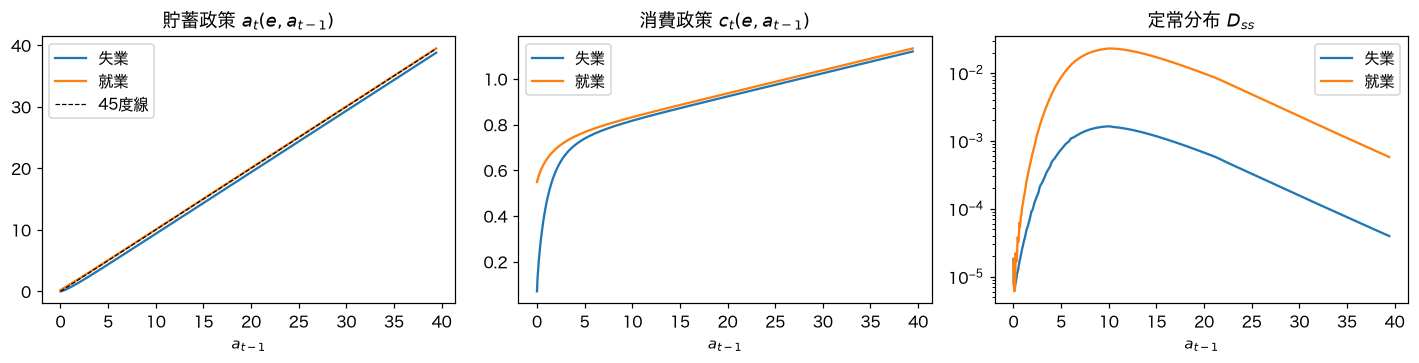

上位   1% が保有する資産の割合 = 0.033
上位  10% が保有する資産の割合 = 0.219
上位  20% が保有する資産の割合 = 0.370
資産のジニ係数                = 0.287

-> KS(1998) が有名な理由のひとつがこれ。米国データでは上位1%が資産の約3割、
   ジニは 0.8 程度だが、このモデルはまったく届かない。beta*(1+r) が 1 に近く
   全員が似た目標資産に向かうため、資産分布が平等になりすぎる。


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))

zoom = p.a_grid <= 40
ax[0].plot(p.a_grid[zoom], ss.a[0][zoom], label='失業')
ax[0].plot(p.a_grid[zoom], ss.a[1][zoom], label='就業')
ax[0].plot(p.a_grid[zoom], p.a_grid[zoom], 'k--', lw=0.8, label='45度線')
ax[0].set_title('貯蓄政策 $a_t(e, a_{t-1})$'); ax[0].set_xlabel('$a_{t-1}$'); ax[0].legend()

ax[1].plot(p.a_grid[zoom], ss.c[0][zoom], label='失業')
ax[1].plot(p.a_grid[zoom], ss.c[1][zoom], label='就業')
ax[1].set_title('消費政策 $c_t(e, a_{t-1})$'); ax[1].set_xlabel('$a_{t-1}$'); ax[1].legend()

ax[2].plot(p.a_grid[zoom], ss.D[0][zoom], label='失業')
ax[2].plot(p.a_grid[zoom], ss.D[1][zoom], label='就業')
ax[2].set_title('定常分布 $D_{ss}$'); ax[2].set_xlabel('$a_{t-1}$'); ax[2].legend()
ax[2].set_yscale('log')

plt.tight_layout(); plt.show()

# 資産分布の集中度
a_all = np.tile(p.a_grid, 2)
w_all = ss.D.ravel()
o = np.argsort(a_all)
a_s, w_s = a_all[o], w_all[o]
cum_pop = np.cumsum(w_s)
share = np.cumsum(w_s * a_s) / np.sum(w_s * a_s)
gini = 1.0 - np.sum(w_s * (np.concatenate(([0.0], share[:-1])) + share))

for q in (0.01, 0.10, 0.20):
    print(f"上位 {q:>4.0%} が保有する資産の割合 = {1 - np.interp(1 - q, cum_pop, share):.3f}")
print(f"資産のジニ係数                = {gini:.3f}")
print()
print("-> KS(1998) が有名な理由のひとつがこれ。米国データでは上位1%が資産の約3割、")
print("   ジニは 0.8 程度だが、このモデルはまったく届かない。beta*(1+r) が 1 に近く")
print("   全員が似た目標資産に向かうため、資産分布が平等になりすぎる。")

---
## 4. ブロック写像 $H$：後ろ向き → 前向き → 集計

`ks.td_household(p, ss, r_path, w_path)` が写像 $H$ そのもの。中身はノート 7.2 の3段階:

```python
# 第1段階: 後ろ向き（終端 V_T = V_ss）
V = ss.Va
for t in reversed(range(T)):
    V, a_path[t], c_path[t] = backward_egm(Pi @ V, a_grid, income(w_path[t]), r_path[t], ...)

# 第2段階 + 第3段階: 前向きに分布を回しつつ集計（初期 D_0 = D_ss）
D = ss.D
for t in range(T):
    K[t] = D . a_path[t]
    C[t] = D . c_path[t]
    D = Pi.T @ forward_endog(D, *lottery(a_path[t]))     # D_{t+1} = Λ_t' D_t
```

**まず基準走行 $Y^0$ を確認する**（ノート 7.7）。価格を定常値に固定して流したとき、
$K^0_t$ が $K_{ss}$ でぴたりと平坦なら、定常状態が数値的に正しく解けている。

In [ ]:
K0, C0 = ks.td_household(p, ss, np.full(T, ss.r), np.full(T, ss.w))
print("基準走行 K^0_t          =", np.array2string(K0, precision=10))
print("K^0_t - K_ss            =", "  ".join(f"{v:+.3e}" for v in K0 - ss.K))
print("C^0_t - C_ss            =", "  ".join(f"{v:+.3e}" for v in C0 - ss.C))
print()
print("-> 1e-12 のオーダーで平坦。定常状態が十分に解けている。")
print("   もしここが例えば 1e-9 だと、eps = 1e-4 で割った瞬間に 1e-5 の誤差になる。")

---
## 5. 章末確認問題1： $T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める

> **問**: $T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める計算順序を記述せよ。

### 手順（ノート 7.2）

**準備**: 基準走行 $K^0$ を、同じ有限期間・同じ終端条件・同じ数値手順で流しておく。

**(1) 摂動経路を作る**（式 7.4）

$$r^{3,+}_t = r_{ss} + \varepsilon \cdot \mathbb{1}\{t = 3\}
\quad\Longrightarrow\quad
r^{3,+} = (r_{ss},\ r_{ss},\ r_{ss},\ r_{ss} + \varepsilon,\ r_{ss})$$

賃金経路は定常値に固定。

**(2) 後ろ向きに政策を求める**（式 7.5）。終端 $V_5 = V_{ss}$ から

$$V^{3,+}_t = v\left(V^{3,+}_{t+1},\ r^{3,+}_t,\ w_{ss}\right), \qquad t = 4, 3, 2, 1, 0$$

同時に $a^{3,+}_t$, $c^{3,+}_t$, $\Lambda^{3,+}_t$ を保存。

**(3) 前向きに分布を求める**（式 7.6）。初期 $D_0 = D_{ss}$ から

$$D^{3,+}_{t+1} = \left(\Lambda^{3,+}_t\right)^{\top} D^{3,+}_t, \qquad t = 0, \dots, 4$$

**(4) 集計して差分をとる**（式 7.7, 7.9）

$$K^{3,+}_t = \left(a^{3,+}_t\right)^{\top} D^{3,+}_t,
\qquad
J^{K,r}_{t,3} \approx \frac{K^{3,+}_t - K^0_t}{\varepsilon}$$

### ここが確認問題2の答えでもある

> **問**: なぜ時点3の金利だけを動かしても、政策を $t = 3$ だけ解けばよいわけではないのか。

$t < 3$ の政策を求めるには**将来の** $r^{3,+}_3$ が必要だから。オイラー方程式
$u'(c_t) = \beta E_t[(1+r_{t+1}) u'(c_{t+1})]$ を通じて、時点3の金利上昇は
時点2の消費・貯蓄を変え、それがさらに時点1・0に伝わる。
だから**終端から時点0までの後ろ向き計算がまるごと必要**になる。

逆に $t > 3$ の政策は $r_4 = r_{ss}$ しか見ないので定常政策のまま。
それでも $K_4$ は動く。理由は**分布** $D_4$ が動いているから（政策効果と分布効果、ノート 4.7・6.5）。

下でこれを実際に確かめる。

In [ ]:
eps = 1e-4

# (1) 摂動経路
r_path = np.full(T, ss.r)
r_path[3] += eps
w_path = np.full(T, ss.w)
print("(1) r 経路 =", np.array2string(r_path, precision=8))

# (2) 後ろ向きに政策を求める（td_household の中身を展開して見る）
a_pert = np.empty((T,) + ss.a.shape)
c_pert = np.empty((T,) + ss.c.shape)
V = ss.Va
for t in reversed(range(T)):
    V, a_pert[t], c_pert[t] = ks.backward_egm(
        p.Pi @ V, p.a_grid, p.income(w_path[t]), r_path[t], p.beta, p.eis)

print("\n(2) 各時点の政策が定常政策からどれだけずれたか  max|a_t - a_ss|:")
for t in range(T):
    tag = "  <- ショックの時点" if t == 3 else ("  <- 将来なので定常のまま" if t > 3 else "")
    print(f"    t = {t}:  {np.max(np.abs(a_pert[t] - ss.a)):.6e}{tag}")

# (3) 前向きに分布を求める
D_pert = np.empty((T,) + ss.D.shape)
D = ss.D.copy()
K_pert = np.empty(T)
for t in range(T):
    D_pert[t] = D
    K_pert[t] = np.vdot(D, a_pert[t])
    D = ks.forward_step(D, p.Pi, *ks.interpolate_coord(p.a_grid, a_pert[t]))

print("\n(3) 各時点の分布が定常分布からどれだけずれたか  max|D_t - D_ss|:")
for t in range(T):
    print(f"    t = {t}:  {np.max(np.abs(D_pert[t] - ss.D)):.6e}")

# (4) 集計して差分
print("\n(4) 集計と差分")
print("    基準走行  K^0_t     =", np.array2string(K0, precision=10))
print("    摂動走行  K^{3,+}_t =", np.array2string(K_pert, precision=10))
col3 = (K_pert - K0) / eps
print("    第3列 J^{K,r}[:, 3] =", np.array2string(col3, precision=6))

**読み方**

- $t < 3$ で $J \ne 0$ ： 時点3の金利上昇を**予見**した家計が、それ以前から貯蓄を変える（ニュース効果、ノート 6.3）。
  値は $t$ が3に近いほど大きい（0.68 → 1.36 → 2.05）。割引されるので遠い将来のニュースほど効きが弱い。
- $t = 3$ で急に大きくなる（13.5） ： ここで実際に $(1+r_3)k_2$ の資本所得が増えるから。
  $K_{ss} \approx 11.6$ なので、$\varepsilon$ の金利上昇は約 $11.6\varepsilon$ の所得増をもたらし、
  その大半が貯蓄に回る。
- $t = 4$ でもほぼ同じ大きさ（13.5） ： 政策はもう定常に戻っているが、**分布**が動いたまま残るから。

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].axhline(0, color='k', lw=0.6)
ax[0].axvline(3, color='r', ls=':', lw=1.2, label='ショックの時点 s = 3')
ax[0].plot(range(T), col3, 'o-')
ax[0].set_title('$J^{K,r}_{:,3}$ : 時点3の金利ニュースへの $K_t$ の反応')
ax[0].set_xlabel('$t$'); ax[0].set_xticks(range(T)); ax[0].legend()

ax[1].axhline(0, color='k', lw=0.6)
ax[1].axvline(3, color='r', ls=':', lw=1.2)
ax[1].plot(range(T), [np.max(np.abs(a_pert[t] - ss.a)) / eps for t in range(T)],
           'o-', label=r'政策のずれ $\max|da_t/dr_3|$')
ax[1].plot(range(T), [np.max(np.abs(D_pert[t] - ss.D)) / eps for t in range(T)],
           's-', label=r'分布のずれ $\max|dD_t/dr_3|$')
ax[1].set_yscale('log'); ax[1].set_xlabel('$t$'); ax[1].set_xticks(range(T))
ax[1].set_title('政策効果と分布効果の分解'); ax[1].legend()

plt.tight_layout(); plt.show()

右の図が「政策効果と分布効果」（ノート 4.7）をきれいに分けている。

- **政策のずれ**は $t \le 3$ で大きく、$t = 4$ でゼロに落ちる（将来の金利は定常なので）
- **分布のずれ**は $t = 0$ でゼロ（初期条件 $D_0 = D_{ss}$）、その後じわじわ増えて $t = 4$ で最大

$K_t$ の反応はこの2つの和である。

---
## 6. 全部の列を並べる → ヤコビアン完成

節5をすべての $s = 0, 1, 2, 3, 4$ と、入力 $r$ と $w$ の両方について繰り返す（ノート 7.3 の図7.1）。

```
 s = 0 の摂動      s = 1 の摂動      ...      s = T-1 の摂動
     ↓                 ↓                          ↓
 後ろ向き T ステップ  後ろ向き T ステップ   ...  後ろ向き T ステップ
     ↓                 ↓                          ↓
 前向き T ステップ    前向き T ステップ     ...  前向き T ステップ
     ↓                 ↓                          ↓
    第0列              第1列                     第T-1列
```

In [ ]:
J = ks.jacobian_direct(p, ss, T=T, h=1e-4, twosided=False)

for key, title in [('K,r', r'$J^{K,r}$'), ('K,w', r'$J^{K,w}$'),
                   ('C,r', r'$J^{C,r}$'), ('C,w', r'$J^{C,w}$')]:
    o, i = key.split(',')
    print(f"{title}   (t, s) 要素 = d{o}_t / d{i}_s     行 t = 応答の時点, 列 s = ショックの時点")
    display(pd.DataFrame(J[key],
                         index=[f't={t}' for t in range(T)],
                         columns=[f's={s}' for s in range(T)]))

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

for s in range(T):
    ax[0].plot(range(T), J['K,r'][:, s], 'o-', label=f'$s={s}$')
ax[0].axhline(0, color='k', lw=0.6)
ax[0].set_title(r'$J^{K,r}$ の列（ニュースとしての列、ノート 6.3）')
ax[0].set_xlabel('$t$'); ax[0].set_xticks(range(T)); ax[0].legend(fontsize=8)

for t in range(T):
    ax[1].plot(range(T), J['K,r'][t, :], 's-', label=f'$t={t}$')
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_title(r'$J^{K,r}$ の行（どの時点のニュースが $K_t$ を動かすか）')
ax[1].set_xlabel('$s$'); ax[1].set_xticks(range(T)); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

**上側と下側に何が入るか**（ノート 6.4）

- **下三角**（$t \ge s$）: ショックが実現した後の反応。政策効果 + 分布効果の両方。大きい。
- **上三角**（$t < s$）: 将来のニュースへの先回り。政策効果だけ（分布はまだ動いていない）。小さい。

$J^{K,r}$ の第0列がどの行でも $\approx 11.4$ とほぼ一定なのは、$t=0$ の金利上昇が
$K_{ss} \approx 11.6$ の資本所得ショックを与え、それがほぼ恒久的に資産に残るから。
$\beta(1+r) \approx 1$ の設定では家計はほぼ恒常所得仮説的にふるまうので、
受け取った資本所得はほとんど取り崩されない。

---
## 7. 精度：片側 vs 中央、$\varepsilon$ の選び方、基準走行

### 7.6 片側差分と中央差分

$$\text{片側}: \frac{h(X^{s,+}) - Y^0}{\varepsilon} = J_{:,s} + O(\varepsilon)
\qquad
\text{中央}: \frac{h(X^{s,+}) - h(X^{s,-})}{2\varepsilon} = J_{:,s} + O(\varepsilon^2)$$

中央差分は精度が良いが計算回数が約2倍。

### 7.6.3 差分幅のトレードオフ

$\varepsilon$ が大きすぎる → 一次近似の外に出る（非線形誤差）。
小さすぎる → 丸め誤差と解法の停止誤差を $\varepsilon$ で割ってしまう。

In [ ]:
truth = ks.jacobian_direct(p, ss, T=T, h=1e-6, twosided=True)   # 真値の代理

rows = []
for h in (1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8):
    e1 = max(np.max(np.abs(ks.jacobian_direct(p, ss, T=T, h=h)[k] - truth[k])) for k in truth)
    e2 = max(np.max(np.abs(ks.jacobian_direct(p, ss, T=T, h=h, twosided=True)[k] - truth[k]))
             for k in truth)
    rows.append({'eps': h, '片側差分の誤差': e1, '中央差分の誤差': e2})
tab = pd.DataFrame(rows).set_index('eps')
display(tab.style.format('{:.3e}'))

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.loglog(tab.index, tab['片側差分の誤差'], 'o-', label='片側差分  $O(\\varepsilon)$')
ax.loglog(tab.index, tab['中央差分の誤差'].clip(lower=1e-16), 's-', label='中央差分  $O(\\varepsilon^2)$')
ax.loglog(tab.index, 2.6 * tab.index, 'k:', lw=0.9, label='傾き 1 の参照線')
ax.set_xlabel(r'$\varepsilon$'); ax.set_ylabel('真値との最大差')
ax.set_title('差分幅のトレードオフ（ノート 7.6.3）'); ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.show()

片側差分の誤差はきれいに $\varepsilon$ に比例している。中央差分は $\varepsilon^2$ で落ちるが、
$\varepsilon$ を小さくしすぎると丸め誤差が効いて**逆に悪化する**。
これがノート 7.6.3 が言う「大きすぎる非線形誤差」と「小さすぎる数値誤差」のトレードオフ。

### 7.7 基準走行 $Y^0$ を差し引く理由

理想的には $Y^0 = Y_{ss}\mathbf{1}$ だが、実際には終端値・補間・グリッド・収束許容誤差のせいで
$Y^0 \ne Y_{ss}\mathbf{1}$ になる。$Y_{ss}\mathbf{1}$ を引くと、摂動と無関係な基準誤差まで
$1/\varepsilon$ 倍されてしまう。

下で、わざと定常状態を甘く解いて実験してみる。

In [ ]:
# わざと定常分布を「反復で 1e-8 まで」しか解かない甘い定常状態を作る
a_i, a_pi = ks.interpolate_coord(p.a_grid, ss.a)
D_sloppy = np.outer(ks.stationary_dist(p.Pi), np.full(p.n_a, 1 / p.n_a))
for it in range(1, 500_001):
    D_new = ks.forward_step(D_sloppy, p.Pi, a_i, a_pi)
    if it % 100 == 0 and np.max(np.abs(D_new - D_sloppy)) < 1e-8:
        D_sloppy = D_new
        break
    D_sloppy = D_new

import dataclasses
ss_sloppy = dataclasses.replace(ss, D=D_sloppy, K=float(np.vdot(D_sloppy, ss.a)))
print(f"甘い定常状態: 反復 {it} 回で停止,  K = {ss_sloppy.K:.8f}  (厳密解 {ss.K:.8f})")

K0_sloppy, _ = ks.td_household(p, ss_sloppy, np.full(T, ss.r), np.full(T, ss.w))
print("\n甘い定常状態での基準走行 K^0_t - K_ss:")
print("   ", "  ".join(f"{v:+.3e}" for v in K0_sloppy - ss_sloppy.K))
print("これを eps = 1e-4 で割ると:", "  ".join(f"{v:+.3e}" for v in (K0_sloppy - ss_sloppy.K) / 1e-4))

# 基準走行を差し引く場合と、Yss を差し引く場合の比較
Js = ks.jacobian_direct(p, ss_sloppy, T=T, h=1e-4)      # 基準走行を差し引いている
r_p = np.full(T, ss.r); r_p[3] += 1e-4
Kp, _ = ks.td_household(p, ss_sloppy, r_p, np.full(T, ss.w))
col3_bad = (Kp - ss_sloppy.K) / 1e-4                     # Yss を差し引いた（悪い）版

print("\n第3列の比較（甘い定常状態のもとで）")
print("  Y^0 を差し引いた   :", np.array2string(Js['K,r'][:, 3], precision=6))
print("  Y_ss を差し引いた  :", np.array2string(col3_bad, precision=6))
print("  真値               :", np.array2string(truth['K,r'][:, 3], precision=6))
print()
print(f"  Y^0 版の誤差   = {np.max(np.abs(Js['K,r'][:, 3] - truth['K,r'][:, 3])):.3e}")
print(f"  Y_ss 版の誤差  = {np.max(np.abs(col3_bad - truth['K,r'][:, 3])):.3e}")

基準走行 $Y^0$ を差し引くと、定常状態の解き方が甘くても共通誤差が相殺されてほとんど影響がない。
$Y_{ss}\mathbf{1}$ を差し引くと、定常状態の誤差がそのまま $1/\varepsilon$ 倍されて残る。
これがノート 7.7 の主張。

---
## 8. 計算量が $O(T^2)$ になること（ノート 7.4, 7.5）

一つの入力について、各列 $s$ を求めるたびに

- おおむね $T$ 回の後ろ向き家計ステップ
- おおむね $T$ 回の前向き分布ステップ

が必要。列は $T$ 本あるので、高価な動的計算の回数は $T \times T = O(T^2)$。
入力が $n_x$ 個なら $O(n_x T^2)$。

### 7.5 どこが重複しているか

時点 $s = 10$ のニュースに対する時点 $t = 3$ の**政策反応**と、
時点 $s = 11$ のニュースに対する時点 $t = 4$ の**政策反応**は、
どちらも「ショックまで7期」なので**同じもの**（定常状態のまわりでは、家計の動的問題は
カレンダー時点ではなくショックまでの距離だけに依存する）。直接法はこれを毎回計算し直している。

ここで言っているのは**政策関数の反応** $\partial a_t / \partial r_s$（グリッド上のベクトル）であって、
ヤコビアンの要素 $J_{t,s}$ ではないことに注意。$J_{t,s}$ は政策反応を分布 $D_t$ で集計したもので、
その $D_t$ はショック以降ずれ続けるので $J_{t,s} \ne J_{t+1,s+1}$ になる。両者の関係が

$$J_{t,s} = J_{t-1,s-1} + F_{t,s}$$

で、この $F$ がフェイクニュース行列（ノート 8.6–8.7）。下で両方を数値的に確かめる。

In [ ]:
h = 1e-6
T20 = 20

def policy_response(s, T_=T20):
    "時点 s の金利ニュースに対する、各時点の政策関数の反応 da_t/dr_s（グリッド上のベクトル）"
    r_path = np.full(T_, ss.r); r_path[s] += h
    V = ss.Va
    out = np.empty((T_,) + ss.a.shape)
    for t in reversed(range(T_)):
        V, out[t], _ = ks.backward_egm(p.Pi @ V, p.a_grid, p.income(ss.w), r_path[t], p.beta, p.eis)
    return (out - ss.a) / h

da10 = policy_response(10)
da11 = policy_response(11)

print("時間並進補題（ノート 8.3）: 政策反応は『ショックまでの距離』だけに依存する")
print(f"    {'距離':>6}  {'max|差|':>12}  {'反応の大きさ':>14}  {'相対差':>10}")
for k in (7, 5, 3, 1, 0):
    lhs, rhs = da10[10 - k], da11[11 - k]
    d = np.max(np.abs(lhs - rhs))
    scale = np.max(np.abs(lhs))
    print(f"    {k:>6}  {d:12.3e}  {scale:14.3e}  {d / scale:10.2e}")
resid = np.max(np.abs(ks.backward_egm(p.Pi @ ss.Va, p.a_grid, ss.y, ss.r, p.beta, p.eis)[1] - ss.a))
print(f"\n-> 残っている絶対差 1.7e-07 は、定常政策そのものの不動点残差 max|a' - a| = {resid:.2e} を")
print(f"   h = {h:g} で割った {resid / h:.2e} とぴたり一致する。つまり補題の破れではなく、")
print("   定常状態を有限精度で解いたことの反映。補題は数値的に厳密に成り立っている。")
print("   直接法は列ごとにこの計算を丸ごとやり直している（ノート 7.5 の重複）。")

J20 = ks.jacobian_direct(p, ss, T=T20, h=1e-6, twosided=True)['K,r']
print("\n一方、ヤコビアンの要素は対角方向にずらすと一致しない（分布 D_t がずれ続けるから）:")
for (t, s) in [(3, 10), (4, 11), (5, 12), (6, 13)]:
    print(f"    J[{t:2d}, {s:2d}] = {J20[t, s]:.10f}")

print("\nその差 F[t, s] = J[t, s] - J[t-1, s-1] がフェイクニュース行列:")
F = J20.copy()
F[1:, 1:] -= J20[:-1, :-1]
for (t, s) in [(3, 10), (4, 11), (5, 12), (6, 13)]:
    print(f"    F[{t:2d}, {s:2d}] = {F[t, s]:.10f}")
print()
print("第8章の要点は、この F が")
print("      F[0, s]  = curlyY[s]                （時点 s のニュースへの時点0の集計反応）")
print("      F[t, s]  = curlyE[t-1] . curlyD[s]  （t >= 1）")
print("と分解できること（ノート 8.6）。curlyY と curlyD は後ろ向き T 回で、")
print("curlyE は定常遷移行列を T 回かけるだけで得られるので、高価な計算は O(T) 回で済む。")
print("F の要素そのものは T x T 個あるが、それは安い内積で埋められる。")

In [ ]:
import time
rows = []
for T_ in (5, 10, 20, 40, 80):
    t0 = time.perf_counter(); ks.jacobian_direct(p, ss, T=T_, h=1e-4); t_dir = time.perf_counter() - t0
    t0 = time.perf_counter(); ks.jacobian_fake_news(p, ss, T=T_, h=1e-4); t_fn = time.perf_counter() - t0
    rows.append({'T': T_, '直接法 (秒)': t_dir, 'fake news (秒)': t_fn, '比': t_dir / t_fn})
tim = pd.DataFrame(rows).set_index('T')
display(tim.style.format({'直接法 (秒)': '{:.4f}', 'fake news (秒)': '{:.4f}', '比': '{:.1f}x'}))

fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.loglog(tim.index, tim['直接法 (秒)'], 'o-', label='直接法')
ax.loglog(tim.index, tim['fake news (秒)'], 's-', label='fake news')
ax.loglog(tim.index, tim['直接法 (秒)'].iloc[0] * (tim.index / 5.0) ** 2, 'k:', lw=0.9, label='$T^2$')
ax.loglog(tim.index, tim['fake news (秒)'].iloc[0] * (tim.index / 5.0), 'k--', lw=0.9, label='$T$')
ax.set_xlabel('$T$'); ax.set_ylabel('秒'); ax.legend(fontsize=8)
ax.set_title('直接法は $O(T^2)$、fake news は $O(T)$')
plt.tight_layout(); plt.show()

---
## 9. sequence-jacobian ライブラリ版と突き合わせ

ここから `.venv` のカーネルが必要（`sequence_jacobian` を import する）。

ライブラリでの家計ブロックの書き方は、自作の `backward_egm` とほぼ一行ずつ対応する:

```python
@het(exogenous='Pi', policy='a', backward='Va', backward_init=hh_init)
def hh(Va_p, a_grid, y, r, beta, eis):
    uc_nextgrid = beta * Va_p                  # Va_p = E_t[Va_{t+1}] は HetBlock が用意
    c_nextgrid  = uc_nextgrid ** (-eis)
    coh = (1 + r) * a_grid[np.newaxis, :] + y[:, np.newaxis]
    a = interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    setmin(a, a_grid[0])
    c = coh - a
    Va = (1 + r) * c ** (-1 / eis)
    return Va, a, c
```

違いは $\Pi \cdot V_{a,t+1}$ の期待計算だけで、それは HetBlock がやってくれる。

**注意**: `return` 文に書いた**変数名**が出力名として読み取られるので、式をそのまま
`return` してはいけない（`return Va` のように必ず名前付きの変数を返す）。

In [ ]:
import sequence_jacobian as sj
import ks_direct_ssj as L

calib = L.build_calibration(p, ss.r, ss.w)

ss_loose = L.hh_ext.steady_state(calib)                  # ライブラリの既定 tol
ss_lib   = L.hh_ext.steady_state(calib, **L.SS_OPTIONS)  # 締めた tol

print(f"自作版            K = {ss.K:.10f}")
print(f"SSJ 既定 tol      A = {ss_loose['A']:.10f}   誤差 = {ss_loose['A'] - ss.K:+.3e}")
print(f"SSJ 締めた tol    A = {ss_lib['A']:.10f}   誤差 = {ss_lib['A'] - ss.K:+.3e}")
print()
print(f"政策の差 max|a_ssj - a_scratch| = {np.max(np.abs(ss_lib.internals['hh']['a'] - ss.a)):.3e}")
print(f"分布の差 max|D_ssj - D_scratch| = {np.max(np.abs(ss_lib.internals['hh']['D'] - ss.D)):.3e}")

既定の許容誤差だと $10^{-4}$ ほどずれる。$\beta(1+r) \approx 0.99990$ で
$\Lambda_{ss}$ の第2固有値が1に近いため、`max|D_new - D| < 1e-10` に達しても
真の定常分布からはまだ $10^{-7}$ 離れている（実測では 33,000 回反復して到達）。

節3で自作版が定常分布を反復ではなく線形方程式で解いていたのはこのため。

In [ ]:
# ヤコビアン4通りを比べる
J_lib      = L.hh_ext.jacobian(ss_lib, inputs=['r', 'w'], outputs=['A', 'C'], T=T)               # 既定: 片側 h=1e-4
J_lib_two  = L.hh_ext.jacobian(ss_lib, inputs=['r', 'w'], outputs=['A', 'C'], T=T, twosided=True)
J_libdir   = L.jacobian_direct_via_library(L.hh_ext, ss_lib, T=T, h=1e-4)
J_scr      = ks.jacobian_direct(p, ss, T=T, h=1e-4)
J_scr_two  = ks.jacobian_direct(p, ss, T=T, h=1e-4, twosided=True)
J_scr_fn   = ks.jacobian_fake_news(p, ss, T=T, h=1e-4, twosided=True)

def mx(A, B): return np.max(np.abs(np.asarray(A) - np.asarray(B)))

print("J^{K,r} (= J^{A,r}) の最大差")
print(f"  自作 直接法(中央)     vs ライブラリ fake news(中央) : {mx(J_scr_two['K,r'], J_lib_two['A']['r']):.3e}")
print(f"  自作 fake news(中央)  vs ライブラリ fake news(中央) : {mx(J_scr_fn['K,r'],  J_lib_two['A']['r']):.3e}")
print(f"  自作 直接法(片側)     vs ライブラリ 直接法(片側)     : {mx(J_scr['K,r'],     J_libdir['A,r']):.3e}")
print()
print(f"  ライブラリ fake news 片側 vs 中央                  : {mx(J_lib['A']['r'],  J_lib_two['A']['r']):.3e}")
print()
display(pd.DataFrame(J_lib_two['A']['r'],
                     index=[f't={t}' for t in range(T)],
                     columns=[f's={s}' for s in range(T)]))

### ここは引っかかりやすいので明記しておく

**ライブラリの `.jacobian()` も有限差分である。** フェイクニュース・アルゴリズムが省くのは
「列ごとに同じ後ろ向き・前向き計算を繰り返す重複」であって、有限差分そのものではない。

ただし微分する対象が違う:

| | 微分する対象 | 誤差の入り方 |
|---|---|---|
| 直接法 | **経路全体の写像** $H$ | 素直に $O(\varepsilon)$ / $O(\varepsilon^2)$ |
| fake news | **1期分の後ろ向きステップ** | その誤差が対角方向の累積を通じて $J$ 全体に伝わる |

そのため既定の片側差分 $h = 10^{-4}$ だと、ライブラリの `.jacobian()` は
直接法（中央差分）と $2.6 \times 10^{-4}$ ほどずれる。
**突き合わせるときは `twosided=True` にするか $h$ を小さくすること。**
上の表で `twosided=True` にすると $10^{-7}$ まで一致する（残りは定常状態のわずかな差）。

もうひとつ: `impulse_nonlinear` は「$Y_{ss}$ からの偏差」を返すのであって
「基準走行 $Y^0$ からの偏差」ではない。直接法に使うなら、ゼロショックの走行を1本流して
差し引くこと（節7で見た通り）。

In [ ]:
# おまけ: 一般均衡の定常状態もライブラリに解かせる（第10・11章の入口）
ks_model = sj.create_model([L.hh_ext, L.firm, L.mkt_clearing], name='Krusell-Smith')
calib_ge = dict(Pi=p.Pi, a_grid=p.a_grid, beta=p.beta, eis=p.eis, lbar=p.lbar,
                unemployment_insurance=p.unemployment_insurance,
                alpha=p.alpha, delta=p.delta, Z=p.Z, N=p.N)
ss_ge = ks_model.solve_steady_state(
    calib_ge, unknowns={'K': (11.58, 40.0 * p.N)}, targets={'asset_mkt': 0.0},
    solver='brentq', options={'hh': L.SS_OPTIONS})
print(f"ライブラリ GE:  K = {ss_ge['K']:.8f}   r = {ss_ge['r']:.8f}   w = {ss_ge['w']:.8f}")
print(f"自作版の二分法との差 |dK| = {abs(ss_ge['K'] - ss.K):.3e}")

---
## 10. ヤコビアンの読み方

### 予算制約からくる恒等式（健全性チェック）

各家計の予算制約 $c_t + k_t = (1+r_t)k_{t-1} + y_t(e_t)$ を分布で集計すると

$$C_t + K_t = (1 + r_t) K_{t-1} + w_t N$$

$t = 0$ について $r_s$ で微分すると（$K_{-1} = K_{ss}$ は所与）

$$\frac{\partial C_0}{\partial r_0} + \frac{\partial K_0}{\partial r_0} = K_{ss},
\qquad
\frac{\partial C_0}{\partial r_s} + \frac{\partial K_0}{\partial r_s} = 0 \quad (s > 0)$$

$w_s$ について微分すると

$$\frac{\partial C_0}{\partial w_0} + \frac{\partial K_0}{\partial w_0} = N,
\qquad
\frac{\partial C_0}{\partial w_s} + \frac{\partial K_0}{\partial w_s} = 0 \quad (s > 0)$$

これはヤコビアンが正しく計算できているかの強力なチェックになる。

In [ ]:
row_r = J['K,r'][0, :] + J['C,r'][0, :]
row_w = J['K,w'][0, :] + J['C,w'][0, :]
print("dC_0/dr_s + dK_0/dr_s =", "  ".join(f"{v:.8f}" for v in row_r))
print(f"                期待値: s=0 で K_ss = {ss.K:.8f}, s>0 で 0")
print(f"                誤差:   s=0 {abs(row_r[0] - ss.K):.3e},  s>0 最大 {np.max(np.abs(row_r[1:])):.3e}")
print()
print("dC_0/dw_s + dK_0/dw_s =", "  ".join(f"{v:.8f}" for v in row_w))
print(f"                期待値: s=0 で N = {p.N:.8f}, s>0 で 0")
print(f"                誤差:   s=0 {abs(row_w[0] - p.N):.3e},  s>0 最大 {np.max(np.abs(row_w[1:])):.3e}")

### なぜ異質的家計ブロックは「密」になるのか（ノート 5.5）

代表的家計モデルなら、オイラー方程式は隣接する時点しか結ばないので
系列空間の行列は帯行列になる。異質的家計ではそうならない:

1. **後ろ向き**に、将来のあらゆる時点の価格が今日の政策に効く（上三角が埋まる）
2. **前向き**に、今日の政策のずれが分布に残り、そのあとの全時点の集計量に効く（下三角が埋まる）

だから $J$ は $T \times T$ の**密行列**になる。ノート 7.4 の注意にあるとおり、
フェイクニュース法が減らすのは高価な動的計算であって、密行列の記憶量 $O(T^2)$ ではない。

### このキャリブレーション特有の性質

$\beta(1+r_{ss}) = 0.99990$ と1に極端に近いので、家計はほぼ恒常所得仮説的にふるまう。
実際、労働所得に対する限界消費性向は

In [ ]:
mpc_w = J['C,w'][0, 0] / p.N
mpc_r = J['C,r'][0, 0] / ss.K
print(f"労働所得1単位あたりの MPC     dC_0/dw_0 / N     = {mpc_w:.5f}")
print(f"資本所得1単位あたりの MPC     dC_0/dr_0 / K_ss  = {mpc_r:.5f}")
print(f"参考: 恒常所得仮説なら r/(1+r) = {ss.r / (1 + ss.r):.5f}")
print()
print("-> どちらも 1% 程度。KS(1998) の beta = 0.99 は非忍耐性の境界に張り付いているので")
print("   家計はきわめて忍耐強く、所得ショックをほとんど消費に回さない。")
print("   HANK の文献で高い MPC を出したいなら、beta を下げるか流動性制約を強める必要がある。")

---
## 11. 章末確認問題 7.11 の答え

**1. $T = 5$ で $J^{K,r}_{:,3}$ を片側差分で求める計算順序を記述せよ。**

節5の通り。まとめると:

0. 基準走行 $K^0$ を、同じ $T$・同じ終端条件・同じ数値手順で流しておく（$\varepsilon = 0$）。
1. $r^{3,+} = (r_{ss}, r_{ss}, r_{ss}, r_{ss}+\varepsilon, r_{ss})$、$w$ は定常値に固定。
2. 終端 $V_5 = V_{ss}$ から $t = 4, 3, 2, 1, 0$ の順に後ろ向きに $V^{3,+}_t$ を解き、
   各時点の $a^{3,+}_t,\ c^{3,+}_t,\ \Lambda^{3,+}_t$ を保存。
3. 初期 $D_0 = D_{ss}$ から $t = 0, \dots, 4$ の順に $D^{3,+}_{t+1} = (\Lambda^{3,+}_t)^{\top} D^{3,+}_t$。
4. 各時点で $K^{3,+}_t = (a^{3,+}_t)^{\top} D^{3,+}_t$ を集計し、
   $J^{K,r}_{t,3} = (K^{3,+}_t - K^0_t)/\varepsilon$。

**2. なぜ時点3の金利だけを動かしても、政策を $t = 3$ だけ解けばよいわけではないのか。**

$t < 3$ の政策を求めるには将来の $r_3$ が必要だから。オイラー方程式
$u'(c_t) = \beta E_t[(1+r_{t+1})u'(c_{t+1})]$ を通じて、時点3の金利は時点2の意思決定に効き、
それが時点1・0へ順に伝わる。だから終端から時点0までの後ろ向き計算がまるごと必要。
節5の出力で、$t = 0, 1, 2$ でも政策が定常からずれていることを確認した。

なお $t > 3$ の政策は定常のまま（将来の価格が定常だから）だが、$K_4$ は動く。
**分布** $D_4$ がすでにずれているから（政策効果と分布効果、ノート 4.7）。

**3. 直接法の高価な家計ステップ数が $O(T^2)$ になることを、列数と各列の計算長から示せ。**

列は $s = 0, \dots, T-1$ の $T$ 本。各列につき

- 後ろ向き家計ステップ: 終端 $T$ から $0$ まで $\approx T$ 回
- 前向き分布ステップ: $0$ から $T-1$ まで $\approx T$ 回

したがって $T \times T = O(T^2)$。入力が $n_x$ 個なら $O(n_x T^2)$。
出力を増やしても後ろ向き計算の回数は増えない（同じ政策・分布から追加の集計量を作れる）が、
保存と集計のコストは増える。節8で $T$ を2倍にすると時間が約4倍になることを実測した。

**4. 中央差分の利点と欠点を述べよ。**

利点: 切断誤差が $O(\varepsilon)$ から $O(\varepsilon^2)$ に落ちる。
節7の表では $\varepsilon = 10^{-4}$ で片側 $2.6\times10^{-4}$ に対し中央 $2.9\times10^{-8}$。

欠点: 摂動走行が正負2本ずつ必要で、計算量が約2倍。
また $\varepsilon$ を小さくしすぎると丸め誤差が支配的になるのは片側と同じで、
$\varepsilon = 10^{-7}$ 以下では逆に悪化する。

**5. 基準走行 $Y^0$ を差し引くことが、特に小さい $\varepsilon$ で重要になる理由。**

有限期間・終端条件・補間・グリッド・収束許容誤差のせいで $Y^0 \ne Y_{ss}\mathbf{1}$ になる。
$Y_{ss}\mathbf{1}$ を差し引くと、この摂動と無関係な基準誤差まで $1/\varepsilon$ 倍される。
$\varepsilon$ が小さいほど倍率が大きいので、$\varepsilon$ を小さくして切断誤差を減らそうとすると
基準誤差の方が爆発する。

同じ有限期間・同じ終端条件・同じ数値手順で走らせた $Y^0$ を差し引けば共通誤差が相殺される。
節7で、わざと甘い定常状態を使って両者を比較した。

---

## まとめ

- 直接法は Sequence Space Jacobian の**定義そのまま**の計算。
  一列ごとに「後ろ向き $T$ ステップ + 前向き $T$ ステップ」を回す。
- 正しいが遅い。列の間の**時間並進**と**分布効果の定常伝播**という2つの重複を使っていないから。
  これを取り除くのが第8章のフェイクニュース・アルゴリズム。
- 直接法の価値は速さではなく、**高速法・解析微分・自動微分を検証する基準**になること（ノート 7.8）。
  実際このノートでは、自作の直接法・自作のフェイクニュース法・ライブラリの3つが
  $10^{-7}$ で一致することを確認した。